# DLWA Analysis: GC-free vs Host-triggered GC

Comparing two zone management strategies on ZNS SSD (ConfZNS++) across different `finish_threshold` values.

- **GC-free** (`gc_mode=False`): zone finished early, no host GC, higher DLWA
- **Host GC** (`gc_mode=True`): delayed FINISH, GC mixes data by lifetime, lower DLWA but GC overhead

In [104]:
import matplotlib.pyplot as plt
import pandas as pd

## Baseline

### Theoretical Calculation

Device: 16 GB, 64 zones → 256 MB/zone, 4 KB page → 65 536 pages/zone  
Workload: 3 M ops × (16 + 1024) B = 3.12 GB → **761 719 pages** of raw data  

For each `finish_threshold` T (%):  
- Zone is finished when remaining space < T%, i.e. after writing `⌊65536 × (1 − T/100)⌋` pages  
- `finish_count = ⌊761719 / pages_at_finish⌋`  
- `total_pages_to_write = finish_count × (65536 − pages_at_finish)` (dummy padding)

In [105]:
import os
import pandas as pd
import matplotlib.pyplot as plt

METRICS = [
    ("total_pages_to_write",  "Dummy Data Writes (LBAs)"),
    ("finish_call_count",     "Finish Call Count"),
    ("latency_micros_per_op", "Latency (µs/op)"),
    ("throughput_MB_per_s",   "Throughput (MB/s)"),
]

def _read_csv(f):
    df = pd.read_csv(f)
    df["occupancy_threshold"] = 100 - df["finish_threshold"]
    return df

def _detect_xcol(df):
    """Return the column that varies: occupancy_threshold or gc_start_level."""
    if df["occupancy_threshold"].nunique() == 1:
        return "gc_start_level"
    return "occupancy_threshold"

def _make_label(df):
    gc_mode = df["gc_mode"].iloc[0]
    xcol    = _detect_xcol(df)
    base    = "Host GC" if gc_mode else "GC-free"
    if xcol == "occupancy_threshold":
        level = df["gc_start_level"].iloc[0]
        suffix = "" if pd.isna(level) or str(level) == "N/A" else f" (level {level})"
    else:
        occ = df["occupancy_threshold"].iloc[0]
        suffix = f" (occ {occ}%)"
    return base + suffix

def plot_baseline(title, files, show_theory=True, yscale="linear"):
    """One line per file. x-axis auto-detected; yscale can be 'linear' or 'log'."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=13)

    num_ops = None
    xcols   = set()
    for f in files:
        df   = _read_csv(f)
        xcol = _detect_xcol(df)
        xcols.add(xcol)
        df   = df.sort_values(xcol)
        if num_ops is None:
            num_ops = int(df["num_ops"].iloc[0])
        label = _make_label(df)
        for ax, (col, _) in zip(axes.flat, METRICS):
            ax.plot(df[xcol], df[col], marker="o", linestyle="--", label=label)

    xlabel = "occupancy_threshold (%)" if "occupancy_threshold" in xcols else "gc_start_level (%)"

    for ax, (_, label) in zip(axes.flat, METRICS):
        ax.set_xlabel(xlabel)
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.set_yscale(yscale)
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [106]:
def plot_metric(title, files, metric, show_theory=True, yscale="linear", figsize=(7, 5)):
    """Plot a single metric for one or more CSV files.

    metric: one of 'total_pages_to_write', 'finish_call_count',
                   'latency_micros_per_op', 'throughput_MB_per_s'
    """
    metric_labels = dict(METRICS)
    if metric not in metric_labels:
        raise ValueError(f"metric must be one of {list(metric_labels)}")

    ylabel = metric_labels[metric]
    fig, ax = plt.subplots(figsize=figsize)
    fig.suptitle(f"{title} — {ylabel}", fontsize=12)

    num_ops = None
    xcols   = set()
    for f in files:
        df   = _read_csv(f)
        xcol = _detect_xcol(df)
        xcols.add(xcol)
        df   = df.sort_values(xcol)
        if num_ops is None:
            num_ops = int(df["num_ops"].iloc[0])
        ax.plot(df[xcol], df[metric], marker="o", linestyle="--", label=_make_label(df))

    xlabel = "occupancy_threshold (%)" if "occupancy_threshold" in xcols else "gc_start_level (%)"



    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [107]:
def plot_baseline_avg(title, file_groups, labels=None, show_theory=False, yscale="linear"):
    """Plot averaged metrics for multiple groups of CSV files.

    file_groups : list of file lists, e.g. [[gc_free1.csv, gc_free2.csv], [gc1.csv, gc2.csv]]
    labels      : optional list of line labels; auto-detected from gc_mode if None
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=13)

    num_ops = None
    xcols   = set()

    for idx, files in enumerate(file_groups):
        dfs  = [_read_csv(f) for f in files]
        xcol = _detect_xcol(dfs[0])
        xcols.add(xcol)

        combined = pd.concat(dfs)
        metric_cols = [col for col, _ in METRICS]
        avg_df = (combined.groupby(xcol)[metric_cols]
                           .mean()
                           .reset_index()
                           .sort_values(xcol))

        if num_ops is None:
            num_ops = int(dfs[0]["num_ops"].iloc[0])

        label = labels[idx] if labels is not None else _make_label(dfs[0])

        for ax, (col, _) in zip(axes.flat, METRICS):
            ax.plot(avg_df[xcol], avg_df[col], marker="o", linestyle="--", label=label)

    xlabel = "occupancy_threshold (%)" if "occupancy_threshold" in xcols else "gc_start_level (%)"

    for ax, (_, ylabel) in zip(axes.flat, METRICS):
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.set_yscale(yscale)
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.tight_layout()
    plt.show()


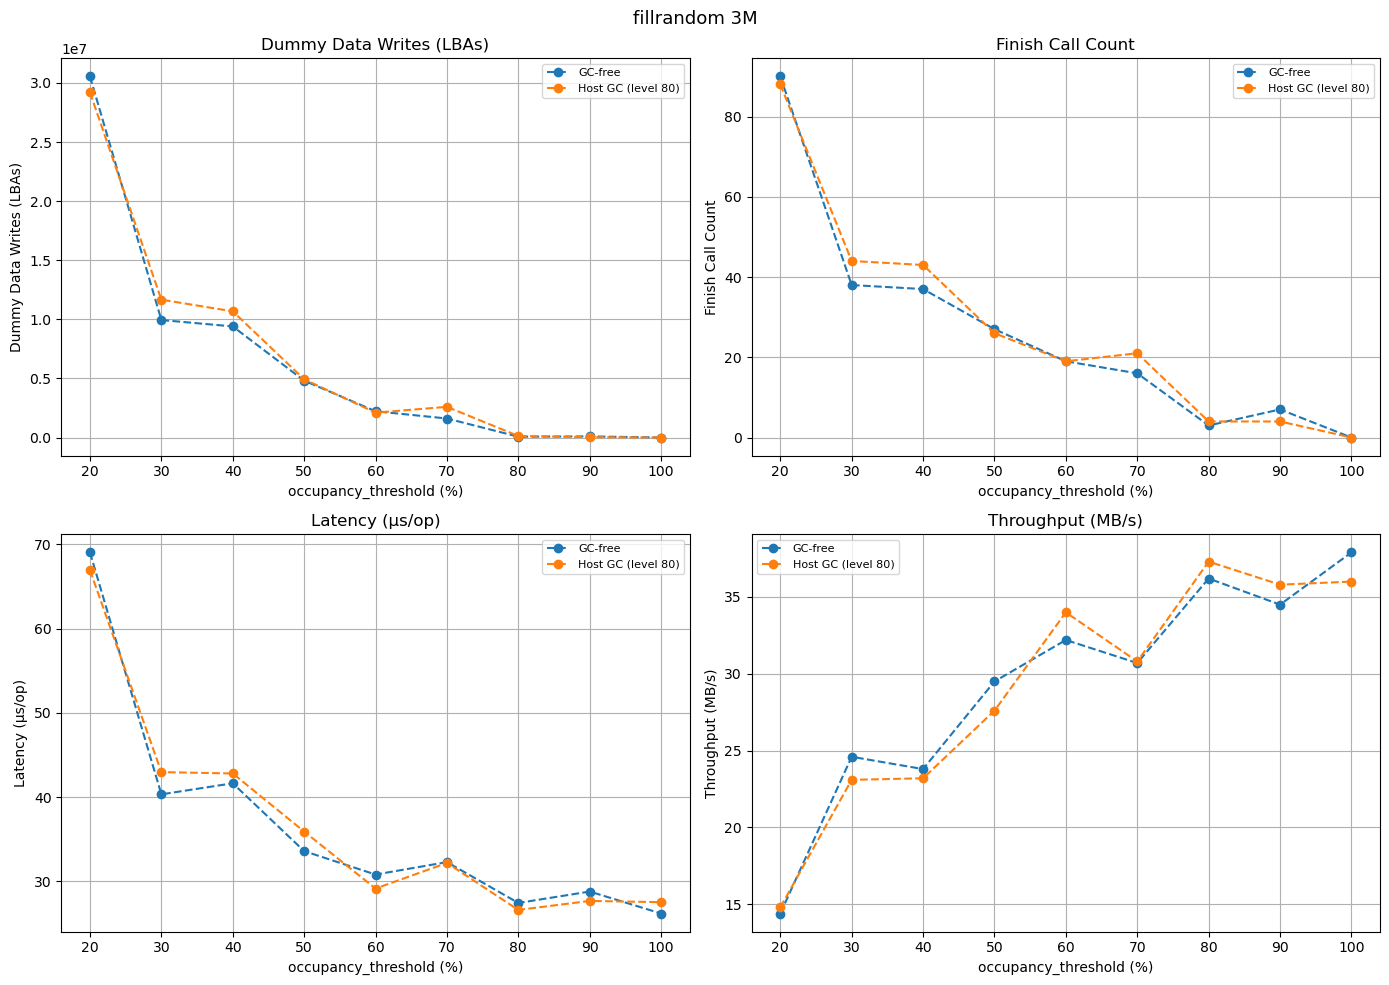

In [108]:
# ── 在这里配置：每个 key 是图的标题，value 是要画在同一张图上的文件列表（一文件一线）──
baseline_plots = {
    "fillrandom 3M": [
        "../results/baseline/fillrandom_3M_2.csv",
        "../results/fillrandom_3M_gc80.csv"
    ],
}

for title, files in baseline_plots.items():
    plot_baseline(title, files)

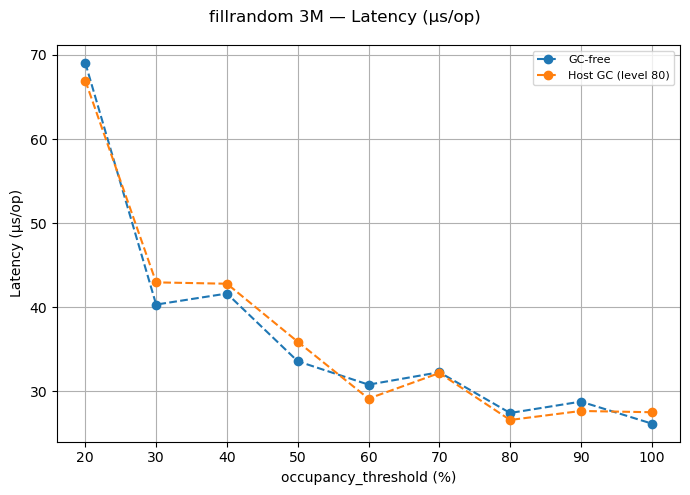

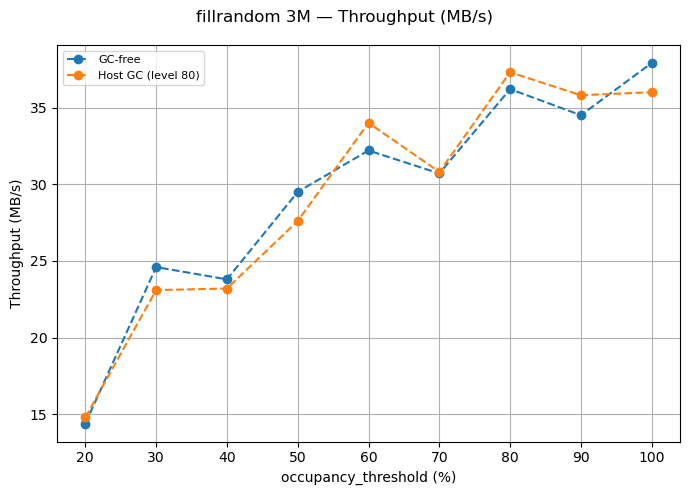

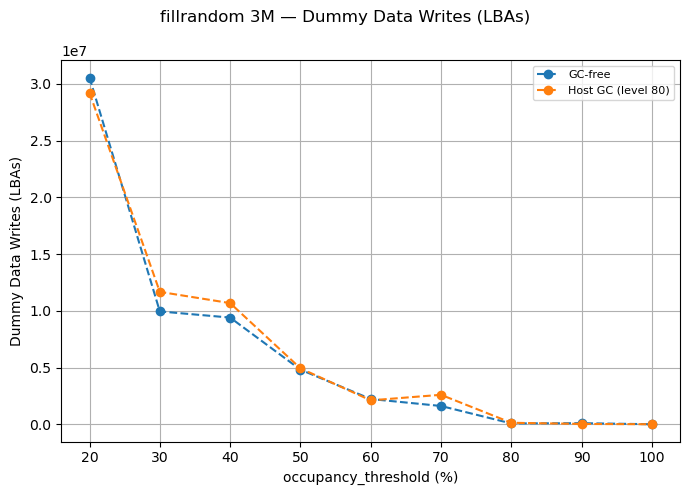

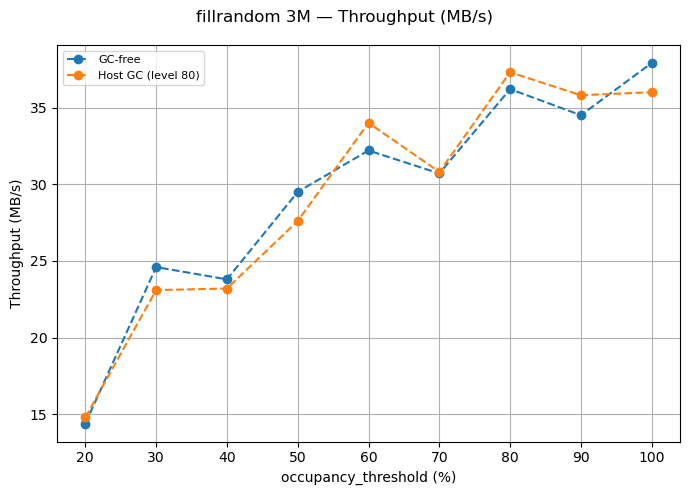

In [109]:
for title, files in baseline_plots.items():
    plot_metric(title, files, metric="latency_micros_per_op")
    plot_metric(title, files, metric="throughput_MB_per_s")
    plot_metric(title, files, metric="total_pages_to_write")
    plot_metric(title, files, metric="throughput_MB_per_s",show_theory=False)


## GC should be helpful under low thresh

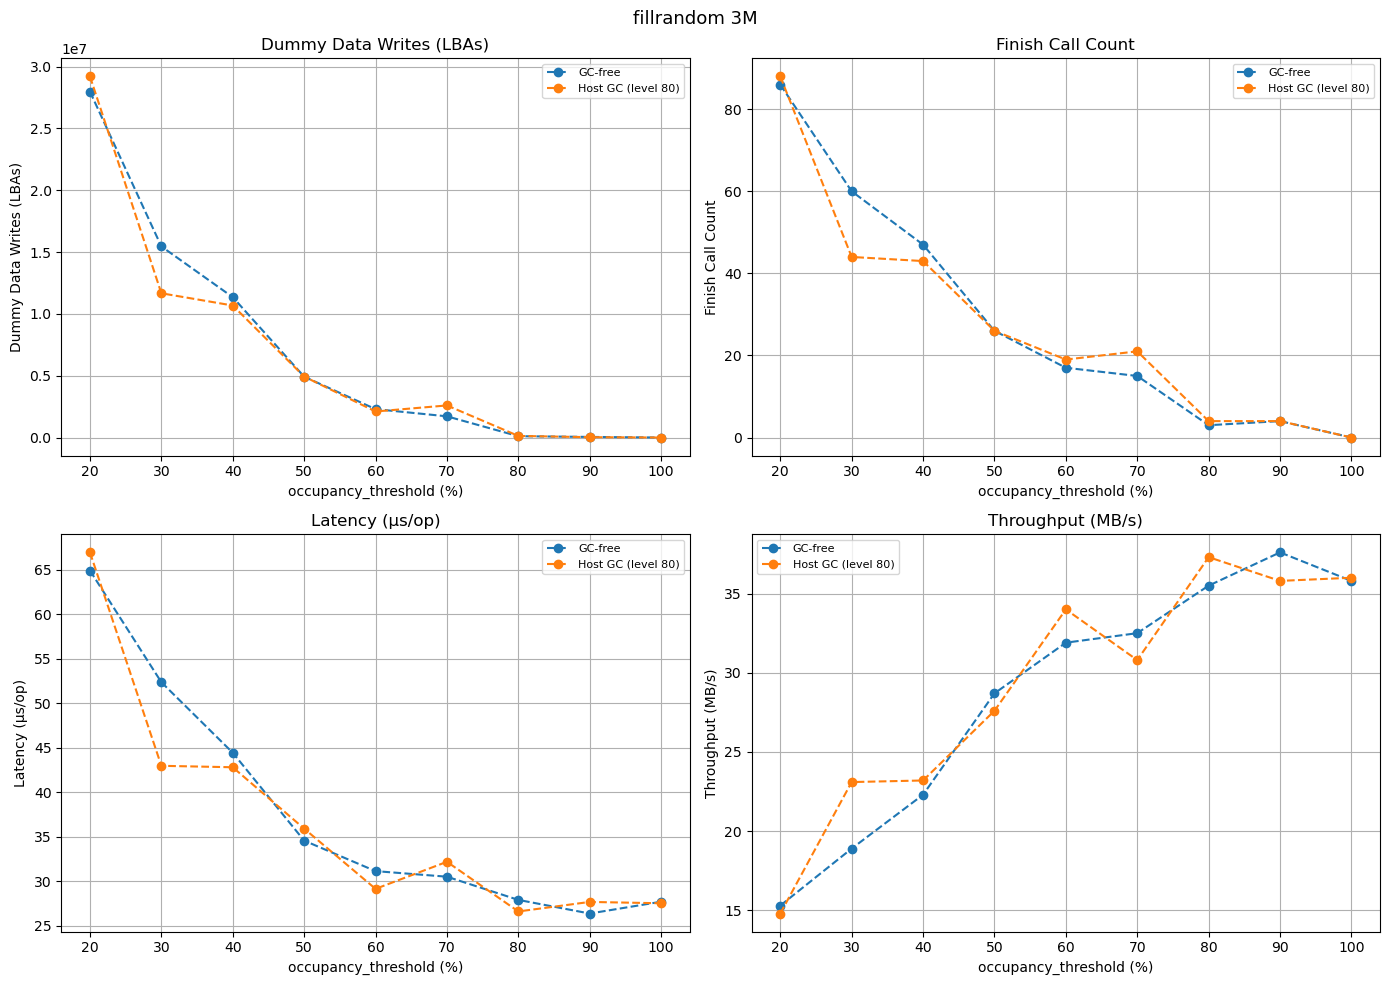

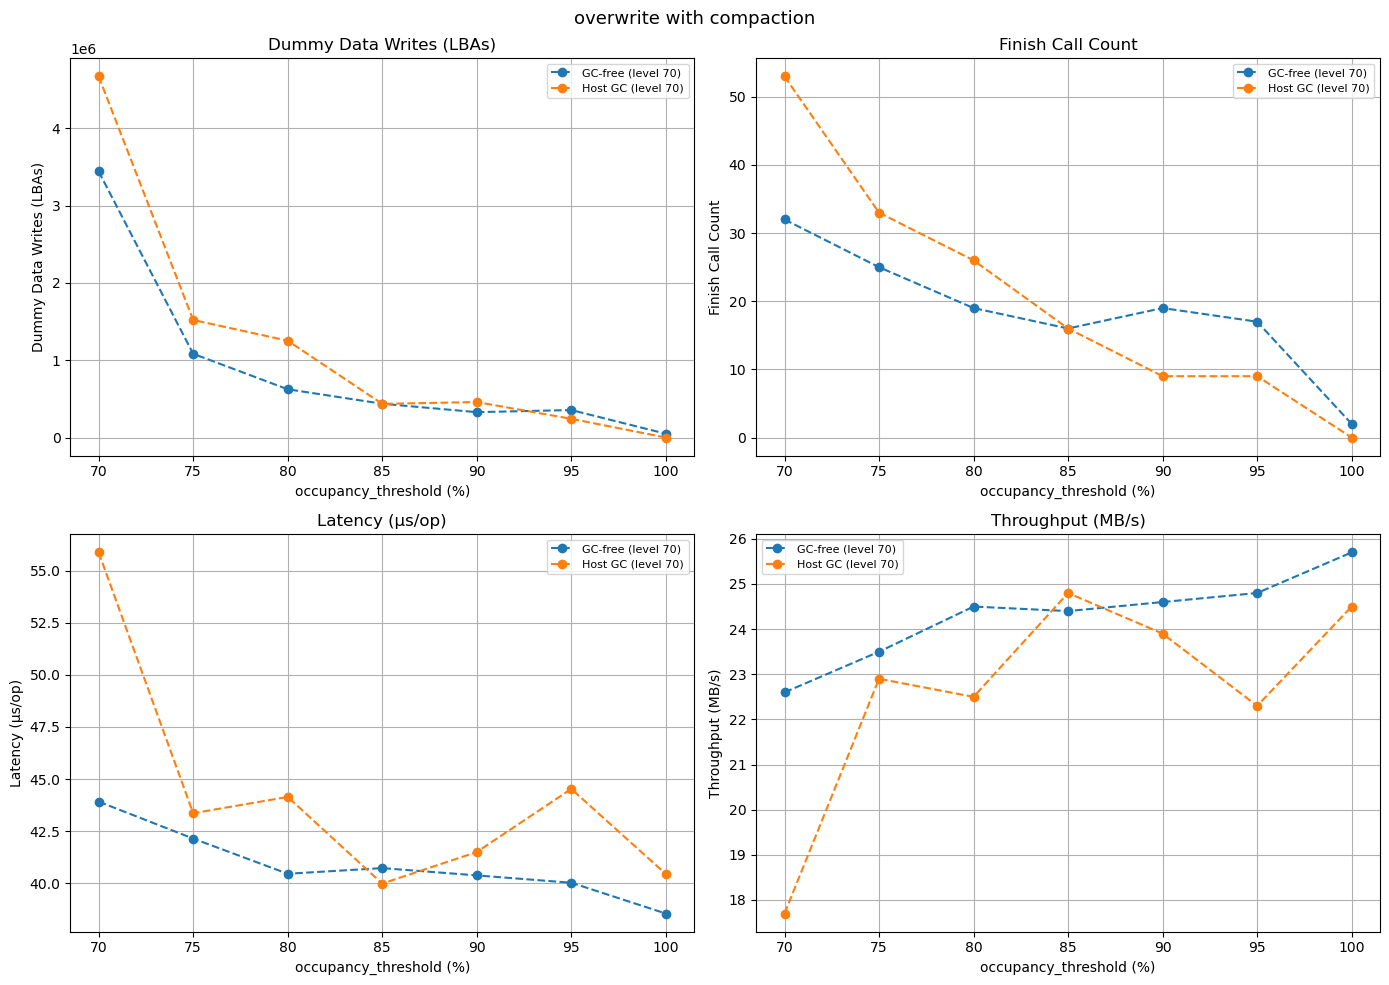

In [110]:
# ── 在这里配置：每个 key 是图的标题，value 是要放进这张图的文件列表 ──
gc_plots = {
    "fillrandom 3M":[
        "../results/baseline/fillrandom_3M_3.csv",
        "../results/fillrandom_3M_gc80.csv",
    ],
    "overwrite with compaction":[
        "../results/baseline/overwrite_3M.csv",
        "../results/overwrite_3M_gc70.csv",
    ],
}

for title, files in gc_plots.items():
    plot_baseline(title, files, show_theory=False)

## Varying gc_start_level



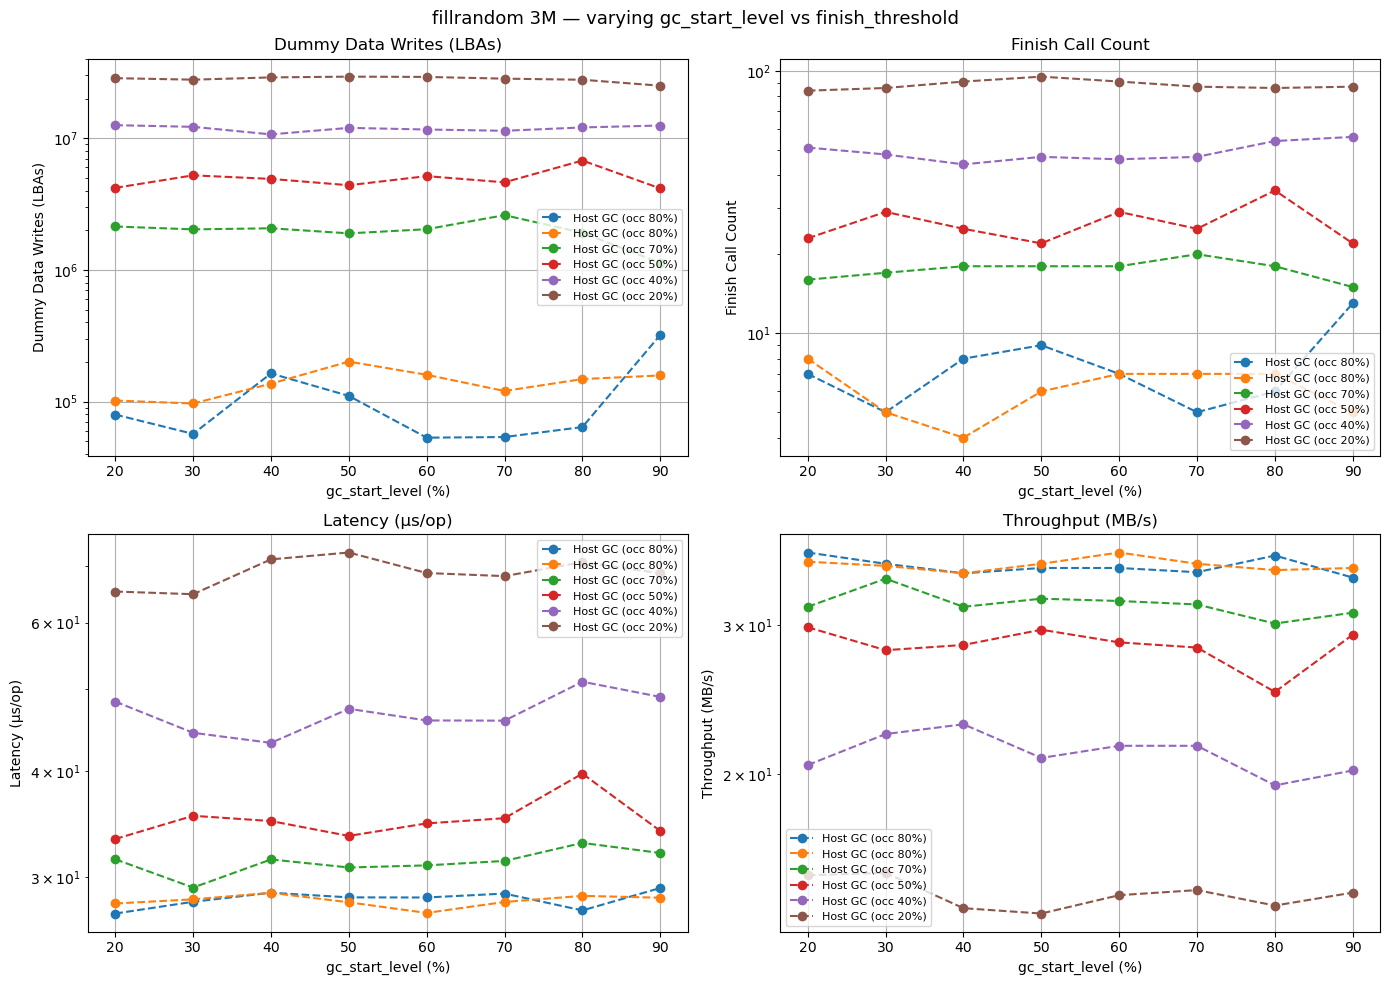

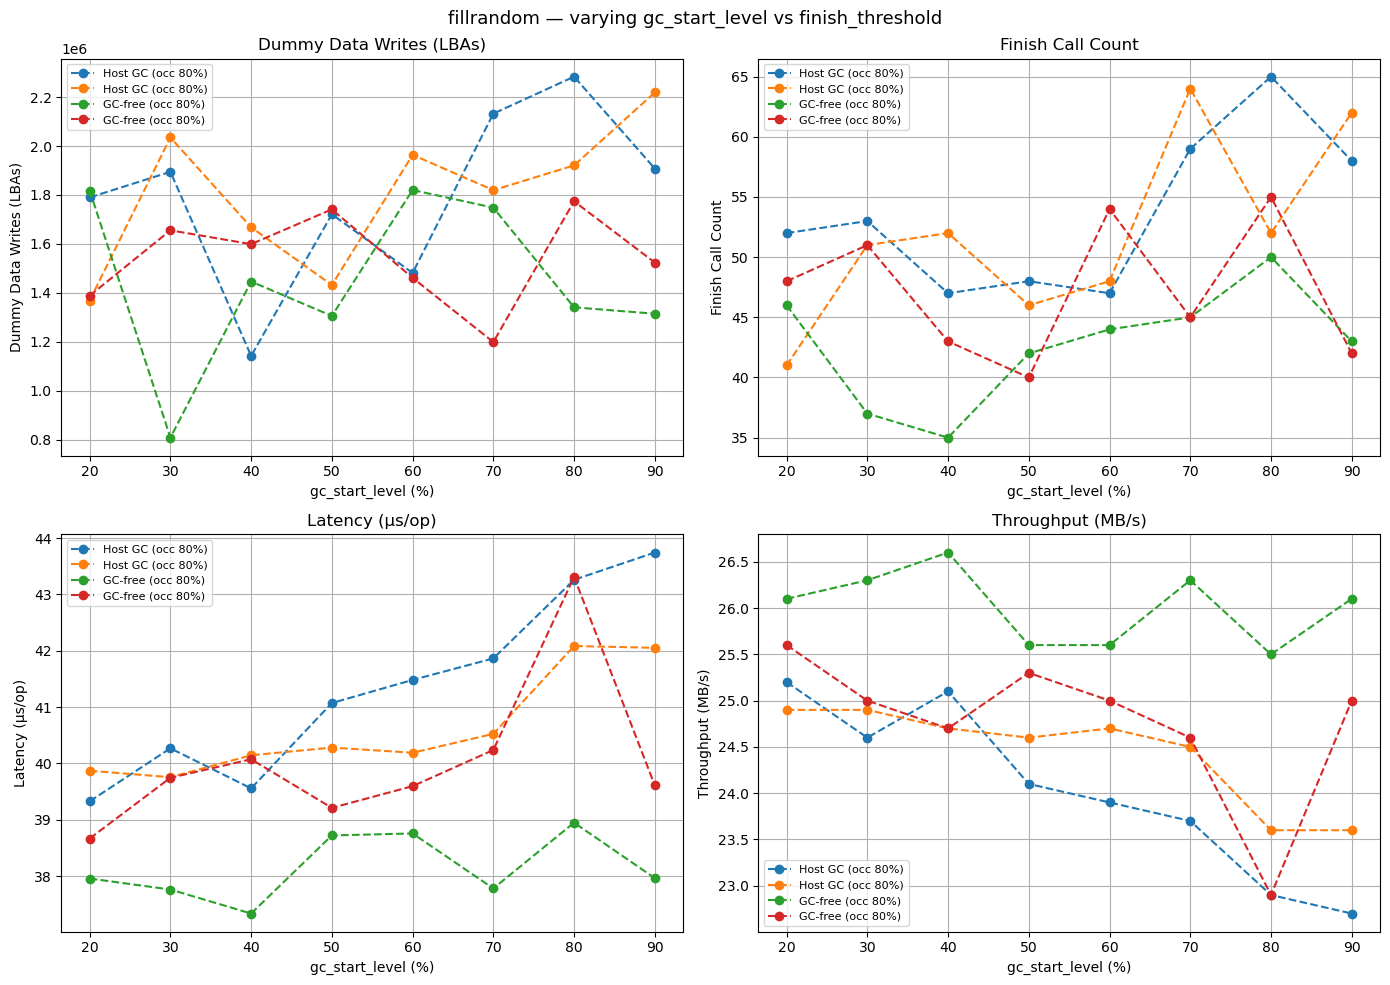

In [111]:
plot_baseline(
    "fillrandom 3M — varying gc_start_level vs finish_threshold",
    [
        "../results/fillrandom_3M_thresh20.csv",
        "../results/fillrandom_3M_thresh20_2.csv",
        "../results/fillrandom_3M_thresh30.csv",
        "../results/fillrandom_3M_thresh50.csv",
        "../results/fillrandom_3M_thresh60.csv",
        "../results/fillrandom_3M_thresh80.csv",
    ],
    show_theory=False,
    yscale="log",
)

plot_baseline(
    "fillrandom — varying gc_start_level vs finish_threshold",
    [
        "../results/fillrandom_7M_thresh20_1.csv",
        "../results/fillrandom_7M_thresh20_2.csv",
        "../results/fillrandom_7M_thresh20_3.csv",
        "../results/fillrandom_7M_thresh20_4.csv",
    ],
    show_theory=False,
)

### Analysis: Is GC orthogonal to FINISH?

#### ZenFS GC selection logic

```cpp
uint64_t threshold = (100 - GC_SLOPE * (gc_start_level_ - free_percent));

for (const auto& zone : snapshot.zones_) {
  if (zone.capacity == 0) {  // only consider already full/finished zones
    uint64_t garbage_percent_approx =
        100 - 100 * zone.used_capacity / zone.max_capacity;
    if (garbage_percent_approx > threshold && garbage_percent_approx < 100) {
      migrate_zones_start.emplace(zone.start);
    }
  }
}
```

GC only reads from zones where `capacity == 0`, i.e. zones that are already full or explicitly FINISH'd. The selection loop never touches active (open) zones. Therefore, **GC and FINISH are orthogonal by design**: `gc_start_level` controls which already-closed zones are migrated, but it does not influence when an active zone gets FINISH'd.

Furthermore, the GC worker does not open a new zone to receive migrated data — it matches the best existing active zone. This means GC migration writes do not increase the total number of open zones, and cannot cause additional FINISH calls by creating new zones that would later need to be finished early.

#### Experimental results

**Figure 1 (3M ops, multiple `finish_threshold` values).**  
At low `finish_threshold` (e.g. 20–30%), the total data written (3M × 1040 B ≈ 3 GB) is not large enough to fill enough zones for GC to trigger. Despite GC being effectively inactive, the `finish_call_count` and `total_pages_to_write` still fluctuate noticeably across different `gc_start_level` values. This confirms the fluctuation is **measurement noise** from the random write pattern, not a causal effect of `gc_start_level`.

**Figure 2 (7M ops, `finish_threshold=20`).**  
With more data (7M ops ≈ 7 GB), GC does trigger. An upward trend in `finish_call_count` at high `gc_start_level` (≥70%) is visible. Given that GC is orthogonal to FINISH both by selection logic and by zone allocation (no new zones opened), this trend is most likely **measurement noise** from the random workload rather than a real GC effect. Confirming this would require more repeated runs.

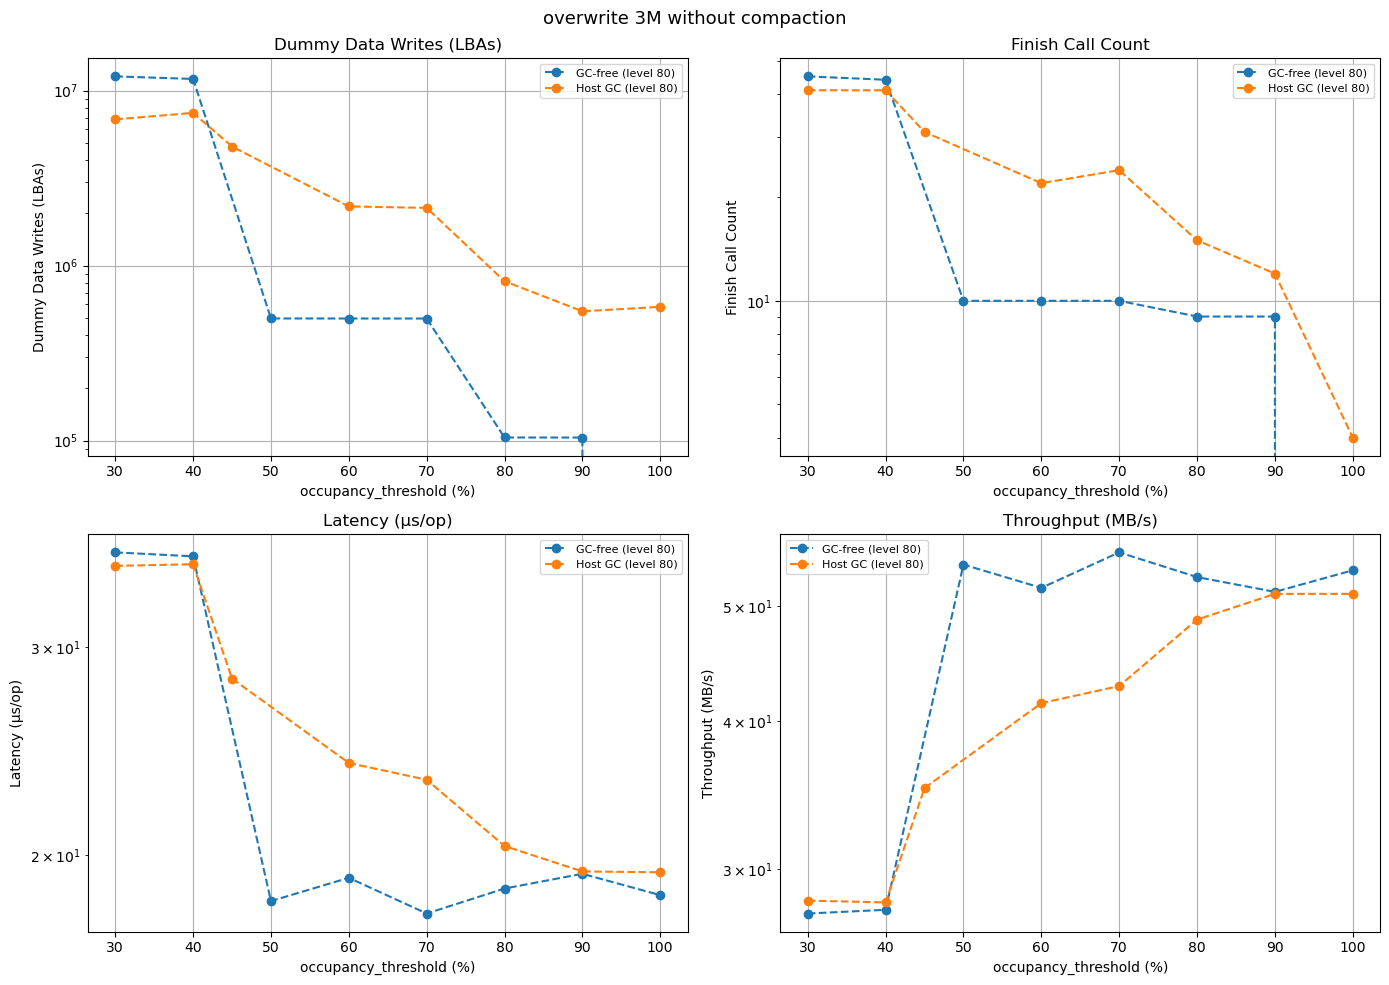

In [112]:
plot_baseline(
    "overwrite 3M without compaction",
    [
        "../results/baseline/overwrite_3M_no_compaction.csv",
        "../results/overwrite_3M_gc80_no_compaction.csv",
    ],
    show_theory=False,
    yscale="log",
)

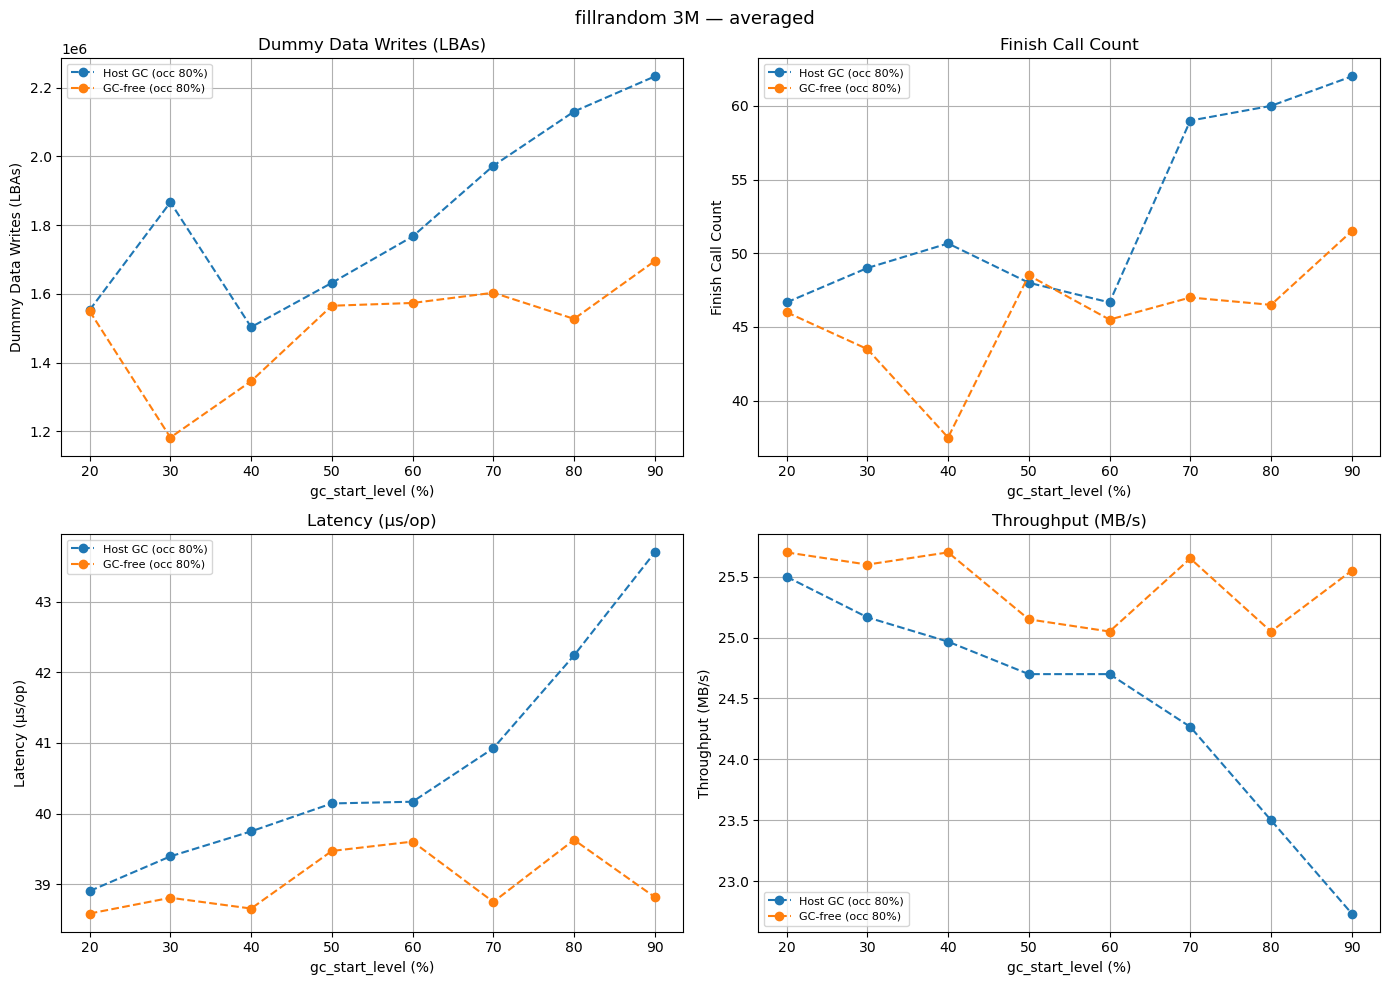

In [120]:
plot_baseline_avg(
    "fillrandom 3M — averaged",
    file_groups=[
        ["../results/fillrandom_7M_thresh20_1.csv", "../results/fillrandom_7M_thresh20_2.csv","../results/fillrandom_7M_thresh20_5.csv"],  # GC 组
        ["../results/fillrandom_7M_thresh20_3.csv",  "../results/fillrandom_7M_thresh20_6.csv"],    # GC-free 组
    ],
    # labels=["GC-free", "Host GC"],  # 不传则自动从 gc_mode 列推断
)